Le tracking automatique a amélioré la qualité des recommandations ?

Étape 1 : chargement des files

In [38]:
import pandas as pd
#Charger AVANT:
before = pd.read_csv("../data/final_interactions.csv", encoding="utf-8")
print(before.shape)

(78101, 6)


In [47]:
import pandas as pd
import psycopg

conn = psycopg.connect(
    host="127.0.0.1",
    dbname="recommender_db",
    user="postgres",
    password="admin",
    port="5432"
)

query = """
SELECT *
FROM recommender_interaction
"""

after = pd.read_sql(query, conn)

print(after.shape)
after.head()
print(after.head())

C:\Users\fatim\AppData\Local\Temp\ipykernel_13476\3705144711.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  after = pd.read_sql(query, conn)


(78135, 6)
   id  rating  course_id  user_id  watch_percentage  \
0   1    10.0          3    98402               0.0   
1   2    10.0          7    98402               0.0   
2   3    10.0         15    98402               0.0   
3   4    10.0         16    98402               0.0   
4   5     1.0         26    98402               0.0   

                        updated_at  
0 2026-04-28 10:22:00.386408+00:00  
1 2026-04-28 10:22:00.386408+00:00  
2 2026-04-28 10:22:00.386408+00:00  
3 2026-04-28 10:22:00.386408+00:00  
4 2026-04-28 10:22:00.386408+00:00  


Étape 2 : Statistiques globales et le Taux d'amélioration

In [48]:
results = pd.DataFrame({
    "Métrique": [
        "Interactions",
        "Utilisateurs",
        "Items"
    ],

    "Avant Tracking": [
        len(before),
        before["user_id"].nunique(),
        before["item_id"].nunique()
    ],

    "Après Tracking": [
        len(after),
        after["user_id"].nunique(),
        after["course_id"].nunique()
    ]
})

results["Amélioration (%)"] = (
    (results["Après Tracking"] -
     results["Avant Tracking"])
    /
    results["Avant Tracking"]
) * 100

print(results.round(2))

       Métrique  Avant Tracking  Après Tracking  Amélioration (%)
0  Interactions           78101           78135              0.04
1  Utilisateurs            4468            4473              0.11
2         Items            1223            1238              1.23


comparer le nombre d'interactions pour quelques utilisateurs :

In [56]:
import pandas as pd
import psycopg

# ==========================
# AVANT TRACKING
# ==========================

# Vérifier les colonnes
print(before.columns)

# ==========================
# APRES TRACKING
# ==========================

conn = psycopg.connect(
    host="127.0.0.1",
    dbname="recommender_db",
    user="postgres",
    password="admin",
    port="5432"
)

after = pd.read_sql("""
SELECT *
FROM recommender_interaction
""", conn)

# ==========================
# UTILISATEURS A COMPARER
# ==========================

users_test = [2, 3, 4400]

results = []

for uid in users_test:

    before_count = len(
        before[before["user_id"] == uid]
    )

    after_count = len(
        after[after["user_id"] == uid]
    )

    results.append([
        uid,
        before_count,
        after_count
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Utilisateur",
        "Avant Tracking",
        "Après Tracking"
    ]
)

comparison["Gain"] = (
    comparison["Après Tracking"]
    - comparison["Avant Tracking"]
)

print(comparison.round(2))

Index(['user_id', 'item_id', 'watch_percentage', 'created_at', 'rating',
       'rating_norm'],
      dtype='object')


C:\Users\fatim\AppData\Local\Temp\ipykernel_13476\1087384456.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  after = pd.read_sql("""


   Utilisateur  Avant Tracking  Après Tracking  Gain
0            2               0              13    13
1            3               0               9     9
2         4400               0               0     0


Representation en graphe :

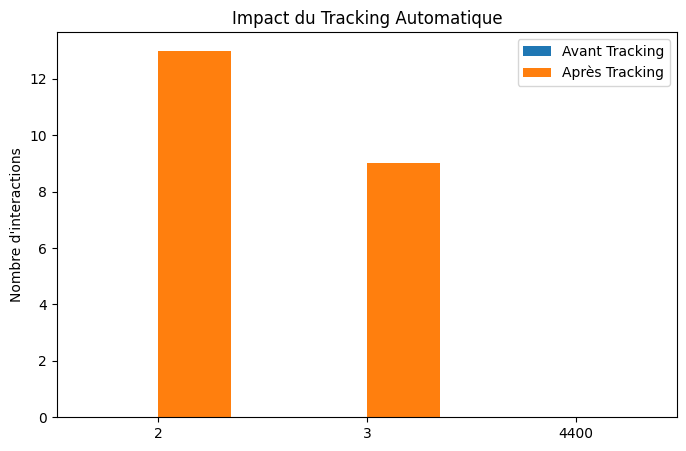

In [52]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(comparison))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    comparison["Avant Tracking"],
    width,
    label="Avant Tracking"
)

plt.bar(
    x + width/2,
    comparison["Après Tracking"],
    width,
    label="Après Tracking"
)

plt.xticks(
    x,
    comparison["Utilisateur"]
)

plt.ylabel("Nombre d'interactions")
plt.title("Impact du Tracking Automatique")
plt.legend()

plt.show()

      user_id  before  after   gain
1586    97911     0.0  862.0  862.0
1715    98478     0.0  814.0  814.0
1596    97997     0.0  677.0  677.0
2801   107897     0.0  522.0  522.0
1612    98127     0.0  498.0  498.0
2130   101631     0.0  494.0  494.0
1179    93181     0.0  471.0  471.0
1169    92928     0.0  469.0  469.0
1636    98366     0.0  415.0  415.0
1471    96469     0.0  386.0  386.0
